In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

In [2]:
TRAIN_PATH = (
    Path("..")
    / "data"
    / "processed"
    / "train_windows.parquet"
)

TEST_PATH = (
    Path("..")
    / "data"
    / "processed"
    / "test_windows.parquet"
)

train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training rows: 7335
Testing rows: 1577


In [3]:
columns_not_used_for_model = [
    "participant_id",
    "recording_id",
    "window_number",
    "start_time_ms",
    "end_time_ms",
    "fog"
]

feature_columns = [
    column
    for column in train_df.columns
    if column not in columns_not_used_for_model
]

X_train = train_df[feature_columns]
y_train = train_df["fog"]

X_test = test_df[feature_columns]
y_test = test_df["fog"]

print("Number of features:", len(feature_columns))

Number of features: 45


In [4]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

In [5]:
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [6]:
predictions = gradient_boosting_model.predict(X_test)

In [7]:
accuracy = accuracy_score(y_test, predictions)

precision = precision_score(
    y_test,
    predictions,
    zero_division=0
)

recall = recall_score(
    y_test,
    predictions,
    zero_division=0
)

f1 = f1_score(
    y_test,
    predictions,
    zero_division=0
)

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1-score:", round(f1, 3))

Accuracy: 0.884
Precision: 0.58
Recall: 0.64
F1-score: 0.608


In [8]:
prediction_report = test_df[
    [
        "participant_id",
        "recording_id",
        "window_number",
        "start_time_ms",
        "end_time_ms",
        "fog"
    ]
].copy()

prediction_report["predicted_fog"] = predictions

prediction_report["start_time_seconds"] = (
    prediction_report["start_time_ms"] / 1000
)

prediction_report["end_time_seconds"] = (
    prediction_report["end_time_ms"] / 1000
)

prediction_report.head()

,participant_id,recording_id,window_number,start_time_ms,end_time_ms,fog,predicted_fog,start_time_seconds,end_time_seconds
0,S02,R01,0,670000,671984,0,0,670.0,671.984
1,S02,R01,1,672000,673984,0,0,672.0,673.984
2,S02,R01,2,674000,675984,0,0,674.0,675.984
3,S02,R01,3,676000,677984,0,0,676.0,677.984
4,S02,R01,4,678000,679984,0,0,678.0,679.984


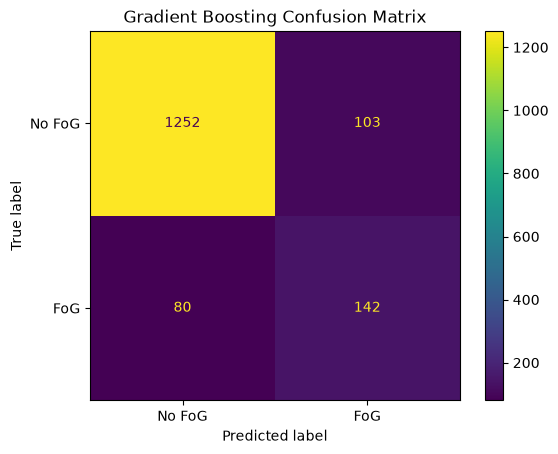

In [9]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["No FoG", "FoG"]
)

plt.title("Gradient Boosting Confusion Matrix")
plt.show()